In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Veriyi okuyalım
df = pd.read_csv('predictive_maintenance.csv')

# Verinin ilk 5 satırına bakalım
print(df.head())

# Verinin genel yapısını görelim (sütun tipleri ve eksik değer kontrolü)
df.info()

Matplotlib is building the font cache; this may take a moment.


  Type  Air temperature  Process temperature  Rotational speed  Torque  \
0    M            298.1                308.6              1551    42.8   
1    L            298.2                308.7              1408    46.3   
2    L            298.1                308.5              1498    49.4   
3    L            298.2                308.6              1433    39.5   
4    L            298.2                308.7              1408    40.0   

   Tool wear  Machine failure  TWF  HDF  PWF  OSF  RNF  
0          0                0    0    0    0    0    0  
1          3                0    0    0    0    0    0  
2          5                0    0    0    0    0    0  
3          7                0    0    0    0    0    0  
4          9                0    0    0    0    0    0  
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Type       

--- Arıza Dağılımı ---
Machine failure
0    0.9661
1    0.0339
Name: proportion, dtype: float64


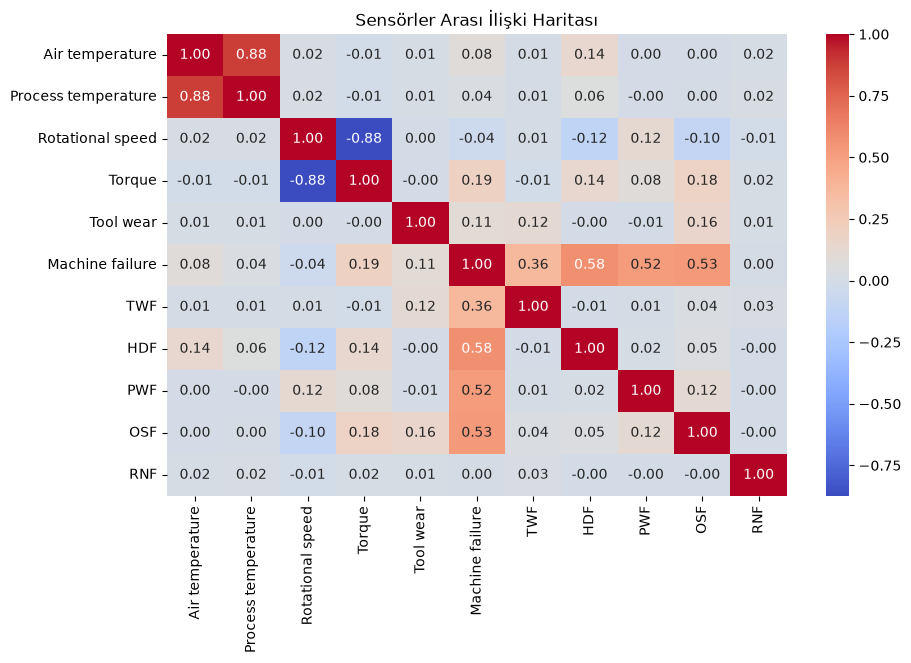

In [2]:
# 1. Hata (Failure) oranlarını kontrol edelim
print("--- Arıza Dağılımı ---")
print(df['Machine failure'].value_counts(normalize=True))

# 2. Korelasyon Matrisi (Hangi sensörler birbirini tetikliyor?)
# 'Type' sütunu kategorik olduğu için onu şimdilik hariç tutuyoruz
plt.figure(figsize=(10, 6))
sns.heatmap(df.drop(columns=['Type']).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Sensörler Arası İlişki Haritası")
plt.show()

In [3]:
# Yeni feature'ları oluşturalım
df['temp_diff'] = df['Process temperature'] - df['Air temperature']
df['power'] = df['Torque'] * df['Rotational speed']
df['wear_x_torque'] = df['Tool wear'] * df['Torque']

# Şimdi bu yeni değişkenlerin Machine failure ile korelasyonuna bakalım
print(df[['Machine failure', 'temp_diff', 'power', 'wear_x_torque']].corr())

                 Machine failure  temp_diff     power  wear_x_torque
Machine failure         1.000000  -0.111676  0.176039       0.190427
temp_diff              -0.111676   1.000000  0.006694      -0.005051
power                   0.176039   0.006694  1.000000       0.368842
wear_x_torque           0.190427  -0.005051  0.368842       1.000000
